# Step 03: Neural Network Training & Modular Visual Benchmark Evaluation

Trains and evaluates deep learning models on pre-split leak-free tensors (`X_train.npy`, `X_val.npy`, `X_test.npy`).

### Modular Model Architecture & Representation Support:
Select any of the 4 supported representations in Cell 1 to preview features, train the neural network, and benchmark performance:
1. **`"cnn"`**: 4D Spatial-Temporal Convolutional Neural Network (`Radar4DCNN` baseline).
2. **`"rep1"`**: Micro-Doppler Spectrogram ResNet-18 model (Velocity Density, Kinetic Energy, Velocity Gradient).
3. **`"rep2"`**: Orthogonal Spatial Projections ResNet-18 model (XY, YZ, XZ projection maps).
4. **`"rep3"`**: Native 3D Point Set PointNet model (X, Y, Z, Doppler, Intensity).

### Strict Zero-Leakage & Safety Policy:
- **Subject/Session Grouping**: Participant files never cross between Train, Val, and Test.
- **Train Set (`X_train.npy`)**: Updates weights via class-weighted Cross-Entropy loss.
- **Validation Set (`X_val.npy`)**: Preserves natural ratio; sweeps thresholds $t \in [0.10, 0.90]$ to optimize Fall $F_1$-score for `[BEST SAVED]` checkpointing.
- **Test Set (`X_test.npy`)**: Evaluated **ONLY ONCE** at the end using the reloaded best model and frozen optimal threshold $t^*$.

In [7]:
# Step 1: Configuration & Single-Point Control
%load_ext autoreload
%autoreload 2
import sys, importlib
sys.path.append("..") if ".." not in sys.path else None

import src.config, src.dataset_utils, src.pipeline, src.trainer, src.representation_utils
importlib.reload(src.config)
importlib.reload(src.dataset_utils)
importlib.reload(src.pipeline)
importlib.reload(src.trainer)
importlib.reload(src.representation_utils)

from src.pipeline import run_model_training
from src.config import DATASET_CONFIGS

# ==============================================================================
# MASTER CONTROL PANEL
# ==============================================================================
dataset_key = "mmfall"   # Options: "mmfall" | "mmwave" | "combined"
model_name = "cnn"       # Options: "cnn" | "rep1" | "rep2" | "rep3"
rep_variant = "raw"      # Rep1: "raw"|"log_scaled"|"smooth" | Rep2: "raw"|"gaussian"|"trail" | Rep3: "raw"|"centered"|"normalized"
epochs = 15              # Default training epochs
lr = 1e-3                # Learning rate
batch_size = 32          # Mini-batch size

print(f"Selected Dataset: {dataset_key.upper()}")
print(f"Selected Model: {model_name.upper()} (Variant: '{rep_variant}')")
print(f"Training Config: epochs={epochs}, lr={lr}, batch_size={batch_size}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Selected Dataset: MMFALL
Selected Model Representation: REP2


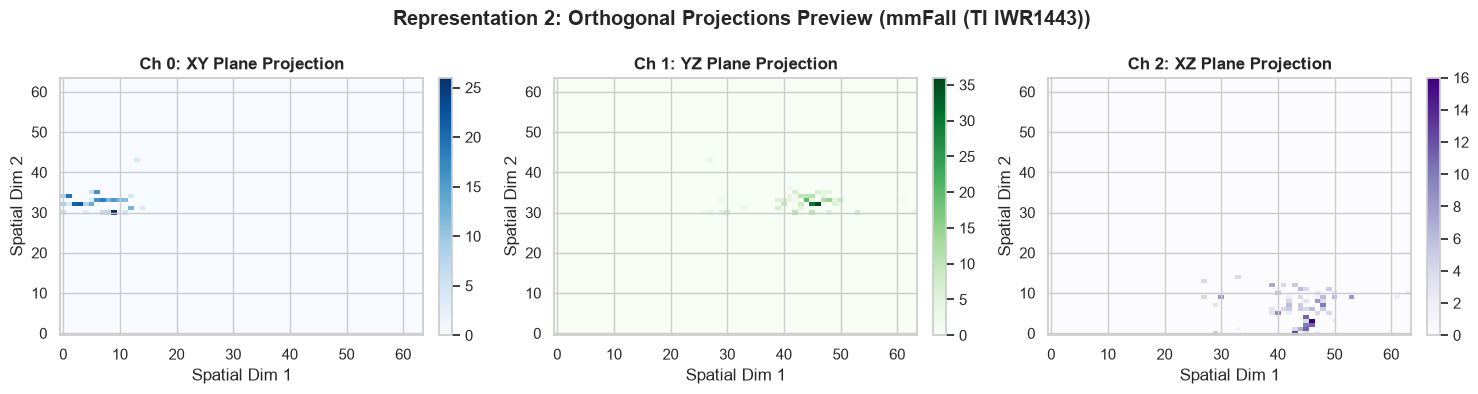

In [8]:
# Visual Evaluation (Confusion Matrix, Metrics Breakdown & Timestamped Parameters)
from src.config import DATASET_CONFIGS, BENCHMARKS_DIR
tag_alias = "mmfall" if dataset_key == "mmfall" else ("ti" if dataset_key == "mmwave" else "combined")
res_json_path = BENCHMARKS_DIR / f"benchmark_results_{tag_alias}.json"
dataset_name = DATASET_CONFIGS[dataset_key].name

if res_json_path.exists():
    bm_res = json.load(open(res_json_path))
    rep_key_map = {
        "cnn": "Radar4DCNN_Baseline",
        "rep1": f"Representation_1_Spectrogram_{rep_variant}",
        "rep2": f"Representation_2_Projections_{rep_variant}",
        "rep3": f"Representation_3_PointNet_{rep_variant}"
    }
    rep_key = rep_key_map.get(model_name, "Radar4DCNN_Baseline")
    if rep_key not in bm_res:
        # Fallback search if exact key variant missing
        matching_keys = [k for k in bm_res.keys() if model_name.lower() in k.lower()]
        rep_key = matching_keys[-1] if len(matching_keys) > 0 else list(bm_res.keys())[-1]
    
    if rep_key in bm_res:
        res_data = bm_res[rep_key]
        cm_matrix = np.array(res_data["confusion_matrix"])
        ts = res_data.get("timestamp", "N/A")
        run_id = res_data.get("run_id", f"benchmark_{rep_key}")
        hparams = res_data.get("hyperparameters", {})
        ep_info = hparams.get("epochs", 15)
        lr_info = hparams.get("lr", 1e-3)
        bs_info = hparams.get("batch_size", 32)
        th_info = res_data.get("optimal_threshold", 0.50)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), dpi=100)
        
        # 1. Confusion Matrix
        sns.heatmap(cm_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
                    xticklabels=["Pred ADL (0)", "Pred Fall (1)"],
                    yticklabels=["Actual ADL (0)", "Actual Fall (1)"])
        axes[0].set_title(f"Confusion Matrix ({rep_key} | {dataset_name})", fontweight="bold", fontsize=11)
        
        tn, fp, fn, tp = cm_matrix.ravel() if cm_matrix.size == 4 else (0,0,0,0)
        axes[0].text(0.5, 0.2, f"TN: {tn}", ha="center", va="center", color="navy", fontsize=11, fontweight="bold")
        axes[0].text(1.5, 0.2, f"FP (False Alarm): {fp}", ha="center", va="center", color="darkred", fontsize=11, fontweight="bold")
        axes[0].text(0.5, 1.2, f"FN (MISSED FALL): {fn}", ha="center", va="center", color="darkred", fontsize=11, fontweight="bold")
        axes[0].text(1.5, 1.2, f"TP (CAUGHT): {tp}", ha="center", va="center", color="darkgreen", fontsize=11, fontweight="bold")
        
        # 2. Performance Metrics
        metrics = ["Accuracy", "Fall Recall", "Fall Precision", "Fall F1-Score", "ROC-AUC"]
        vals = [res_data["accuracy"], res_data["recall"], res_data["precision"], res_data["f1_score"], res_data["roc_auc"]]
        colors = ["#3498db", "#2ecc71", "#9b59b6", "#e74c3c", "#f39c12"]
        
        bars = axes[1].bar(metrics, [v*100 for v in vals], color=colors, edgecolor="black", width=0.55)
        axes[1].set_ylim(0, 115)
        axes[1].set_ylabel("Percentage (%) / Score")
        axes[1].set_title(f"Performance Summary ({rep_key} | {dataset_name})", fontweight="bold", fontsize=11)
        axes[1].set_xticklabels(metrics, rotation=15, ha="right")
        
        for bar in bars:
            h = bar.get_height()
            axes[1].text(bar.get_x() + bar.get_width()/2.0, h + 2, f"{h:.1f}%", ha="center", va="bottom", fontweight="bold", fontsize=10)
            
        title_text = f"Model Evaluation Summary: Model='{model_name.upper()}' ({rep_key}) | Dataset='{dataset_key.upper()}' ({dataset_name})\nParameters: epochs={ep_info}, lr={lr_info}, batch_size={bs_info}, $t^*={th_info:.2f}$ | Run Date: {ts}"
        plt.suptitle(title_text, fontweight="bold", fontsize=12, y=1.04)
        plt.tight_layout()
        
        # Save exact matching PNG figure alongside JSON run file
        run_png_path = BENCHMARKS_DIR / f"{run_id}.png"
        plt.savefig(run_png_path, bbox_inches="tight", dpi=300)
        print(f"Saved matching benchmark plot image to: {run_png_path}")
        plt.show()
else:
    print(f"No benchmark results found yet at {res_json_path}. Run training step first!")

In [9]:
# Step 2: Execute Model Training and Evaluation
acc, auc, cm = run_model_training(dataset_key, model_name=model_name, epochs=epochs, lr=lr, batch_size=batch_size, variant=rep_variant)

=== Starting Training for model='rep2' on dataset='mmfall' ===

--- Training Representation_2_Projections on mmFall (TI IWR1443) (epochs=15, lr=0.001, batch_size=32) ---
Epoch [01/15] Tr Loss: 0.6454, Acc: 64.26% | Val Loss: 1.2778, Acc: 56.50%, F1: 3.25%, Rec: 74.19% (Thresh: 0.74) [BEST SAVED]
Epoch [05/15] Tr Loss: 0.4756, Acc: 76.80% | Val Loss: 0.3399, Acc: 85.43%, F1: 4.47%, Rec: 34.68% (Thresh: 0.54) [BEST SAVED]
Epoch [10/15] Tr Loss: 0.3656, Acc: 83.93% | Val Loss: 0.6139, Acc: 84.57%, F1: 5.35%, Rec: 44.35% (Thresh: 0.78) [BEST SAVED]
Epoch [15/15] Tr Loss: 0.2975, Acc: 87.87% | Val Loss: 0.0569, Acc: 97.60%, F1: 7.34%, Rec: 9.68% (Thresh: 0.12) [BEST SAVED]

--- Test Results: Representation_2_Projections (Frozen Val Decision Threshold: 0.12) ---
Test Accuracy: 93.00% | ROC-AUC: 0.7719 | Recall: 3.95% | Precision: 24.00% | F1: 6.78%
Saved benchmark results to: C:\Users\joeyw\GitProjects\mmWaves-Fall-Detection\models\benchmarks\benchmark_results_mmfall.json


C:\Users\joeyw\AppData\Local\Temp\ipykernel_17640\2922248815.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(metrics, rotation=15, ha="right")


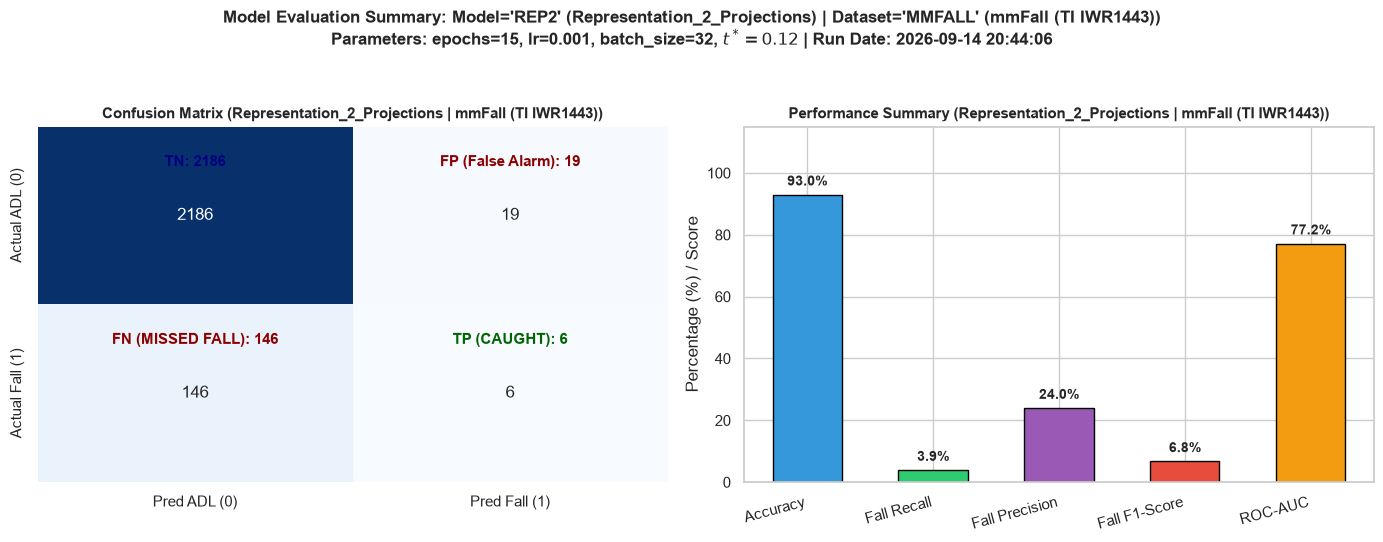

In [10]:
# Visual Evaluation (Confusion Matrix, Metrics Breakdown & Timestamped Parameters)
from src.config import DATASET_CONFIGS, BENCHMARKS_DIR
tag_alias = "mmfall" if dataset_key == "mmfall" else ("ti" if dataset_key == "mmwave" else "combined")
res_json_path = BENCHMARKS_DIR / f"benchmark_results_{tag_alias}.json"
dataset_name = DATASET_CONFIGS[dataset_key].name

if res_json_path.exists():
    bm_res = json.load(open(res_json_path))
    rep_key_map = {
        "cnn": "Radar4DCNN_Baseline",
        "rep1": f"Representation_1_Spectrogram_{rep_variant}",
        "rep2": f"Representation_2_Projections_{rep_variant}",
        "rep3": f"Representation_3_PointNet_{rep_variant}"
    }
    rep_key = rep_key_map.get(model_name, "Radar4DCNN_Baseline")
    if rep_key not in bm_res:
        # Fallback search if exact key variant missing
        matching_keys = [k for k in bm_res.keys() if model_name.lower() in k.lower()]
        rep_key = matching_keys[-1] if len(matching_keys) > 0 else list(bm_res.keys())[-1]
    
    if rep_key in bm_res:
        res_data = bm_res[rep_key]
        cm_matrix = np.array(res_data["confusion_matrix"])
        ts = res_data.get("timestamp", "N/A")
        run_id = res_data.get("run_id", f"benchmark_{rep_key}")
        hparams = res_data.get("hyperparameters", {})
        ep_info = hparams.get("epochs", 15)
        lr_info = hparams.get("lr", 1e-3)
        bs_info = hparams.get("batch_size", 32)
        th_info = res_data.get("optimal_threshold", 0.50)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), dpi=100)
        
        # 1. Confusion Matrix
        sns.heatmap(cm_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
                    xticklabels=["Pred ADL (0)", "Pred Fall (1)"],
                    yticklabels=["Actual ADL (0)", "Actual Fall (1)"])
        axes[0].set_title(f"Confusion Matrix ({rep_key} | {dataset_name})", fontweight="bold", fontsize=11)
        
        tn, fp, fn, tp = cm_matrix.ravel() if cm_matrix.size == 4 else (0,0,0,0)
        axes[0].text(0.5, 0.2, f"TN: {tn}", ha="center", va="center", color="navy", fontsize=11, fontweight="bold")
        axes[0].text(1.5, 0.2, f"FP (False Alarm): {fp}", ha="center", va="center", color="darkred", fontsize=11, fontweight="bold")
        axes[0].text(0.5, 1.2, f"FN (MISSED FALL): {fn}", ha="center", va="center", color="darkred", fontsize=11, fontweight="bold")
        axes[0].text(1.5, 1.2, f"TP (CAUGHT): {tp}", ha="center", va="center", color="darkgreen", fontsize=11, fontweight="bold")
        
        # 2. Performance Metrics
        metrics = ["Accuracy", "Fall Recall", "Fall Precision", "Fall F1-Score", "ROC-AUC"]
        vals = [res_data["accuracy"], res_data["recall"], res_data["precision"], res_data["f1_score"], res_data["roc_auc"]]
        colors = ["#3498db", "#2ecc71", "#9b59b6", "#e74c3c", "#f39c12"]
        
        bars = axes[1].bar(metrics, [v*100 for v in vals], color=colors, edgecolor="black", width=0.55)
        axes[1].set_ylim(0, 115)
        axes[1].set_ylabel("Percentage (%) / Score")
        axes[1].set_title(f"Performance Summary ({rep_key} | {dataset_name})", fontweight="bold", fontsize=11)
        axes[1].set_xticklabels(metrics, rotation=15, ha="right")
        
        for bar in bars:
            h = bar.get_height()
            axes[1].text(bar.get_x() + bar.get_width()/2.0, h + 2, f"{h:.1f}%", ha="center", va="bottom", fontweight="bold", fontsize=10)
            
        title_text = f"Model Evaluation Summary: Model='{model_name.upper()}' ({rep_key}) | Dataset='{dataset_key.upper()}' ({dataset_name})\nParameters: epochs={ep_info}, lr={lr_info}, batch_size={bs_info}, $t^*={th_info:.2f}$ | Run Date: {ts}"
        plt.suptitle(title_text, fontweight="bold", fontsize=12, y=1.04)
        plt.tight_layout()
        
        # Save exact matching PNG figure alongside JSON run file
        run_png_path = BENCHMARKS_DIR / f"{run_id}.png"
        plt.savefig(run_png_path, bbox_inches="tight", dpi=300)
        print(f"Saved matching benchmark plot image to: {run_png_path}")
        plt.show()
else:
    print(f"No benchmark results found yet at {res_json_path}. Run training step first!")

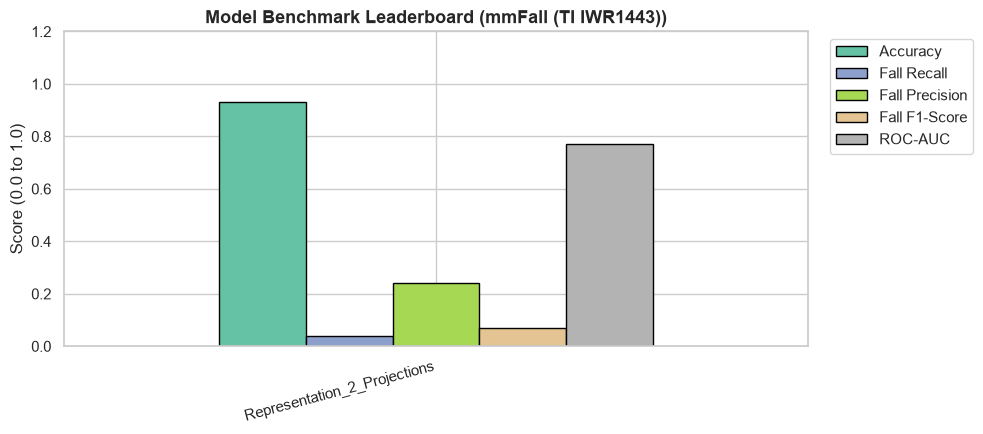

In [11]:
# Multi-Model Benchmark Comparison Leaderboard
from src.config import DATASET_CONFIGS, BENCHMARKS_DIR
tag_alias = "mmfall" if dataset_key == "mmfall" else ("ti" if dataset_key == "mmwave" else "combined")
res_json_path = BENCHMARKS_DIR / f"benchmark_results_{tag_alias}.json"

if res_json_path.exists():
    bm_res = json.load(open(res_json_path))
    if len(bm_res) > 0:
        df_bench = pd.DataFrame(bm_res).T
        fig, ax = plt.subplots(figsize=(10, 4.5), dpi=100)
        df_bench[["accuracy", "recall", "precision", "f1_score", "roc_auc"]].plot(kind="bar", ax=ax, colormap="Set2", edgecolor="black", width=0.7)
        ax.set_title(f"Model Benchmark Leaderboard ({DATASET_CONFIGS[dataset_key].name})", fontweight="bold", fontsize=13)
        ax.set_ylabel("Score (0.0 to 1.0)")
        ax.set_ylim(0, 1.2)
        ax.legend(["Accuracy", "Fall Recall", "Fall Precision", "Fall F1-Score", "ROC-AUC"], bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.xticks(rotation=15, ha="right")
        plt.tight_layout()
        plt.show()
else:
    print("No benchmark results available to plot leaderboard yet.")